In [39]:
# Import all the tools we need

# Regular EDA (Exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to appear inside the notebook
%matplotlib inline 

# Data Transformation
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Models from Scikit-Learn
from sklearn.ensemble import RandomForestClassifier


# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [38]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


Here is the step-by-step sequence of te project:

1. **Load the data**

2. **Exploratory Data Analysis (EDA)**: Check the raw data to find patterns (like noticing that "Master" in the Name column correlates with survival).

3. **Define Custom Transformers**: Write AgeCategoryTransformer and TitleExtractor classes.

4. **Assemble the Pipeline and Optimization :** Bundle the tools, standard scalers, and model (Random Forest) into one single object.
Instead of fitting the model once,  try 10 different versions of the settings (different age bins, different number of trees). It uses Cross-Validation internally to find the "winner."

6. **The Final Fit**: Once GridSearchCV finds the best settings, it automatically performs a final fit on your entire training set using those "winning" parameters.

7. **The Test Prediction**: Ppass the raw, test_data into the optimized GridSearchCV object. It cleans the data and makes the final survival predictions.



# 1. Load the data

1. **survival**	Survival	0 = No, 1 = Yes
2. **pclass**	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
3. **sex**	Sex
4. **Age**	Age in years
5. **sibsp**	# of siblings / spouses aboard the Titanic
6. **parch**	# of parents / children aboard the Titanic
7. **ticket**	Ticket number
8. **fare**	Passenger fare
9. **cabin**	Cabin number
10. **embarked**	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton


In [40]:
# Load the train data
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
# Load the test data
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


The column 'Survived' of the test data will be predicted by the model

In [42]:
# Check the train and the test data shape
train_data.shape, test_data.shape

((891, 12), (418, 11))

# 2. Exploratory Data Analysis (EDA)

## 2.1 Overview

In [43]:
# Check the basic info of the data
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


There are 5 columns that need the transformation later in order to put to the model: Name, Sex, Ticket, Cabin, and Embarked.

Some columns have missing data -> check in the next step.

In [44]:
#  Check how many the data is missing
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are 3 columns that have missing data: Age, Cabin, and Embarked. In the Cabin clumn, the missing data is 77% -> to check if we should keep or drop.

In [45]:
# Display the statistical descrption of train_data
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2.2 Exploring the "Sex" column

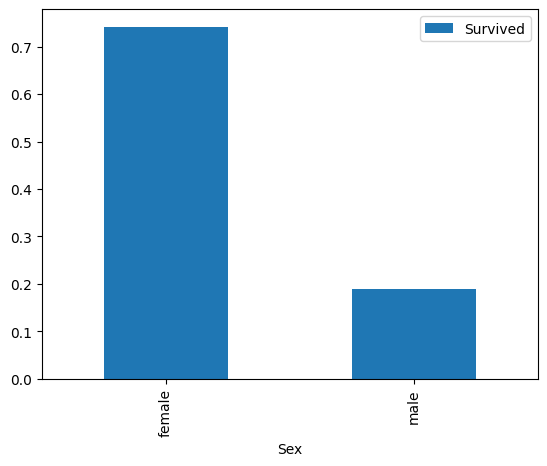

In [46]:
# Check how 'Sex' related to Survived
sex_pivot = train_data.pivot_table(index="Sex",values="Survived")
sex_pivot.plot.bar()
plt.show()

From the graph, females survived in much higher proportions than males did.

## 2.3 Exploring the "Age" column

In [47]:
train_data["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

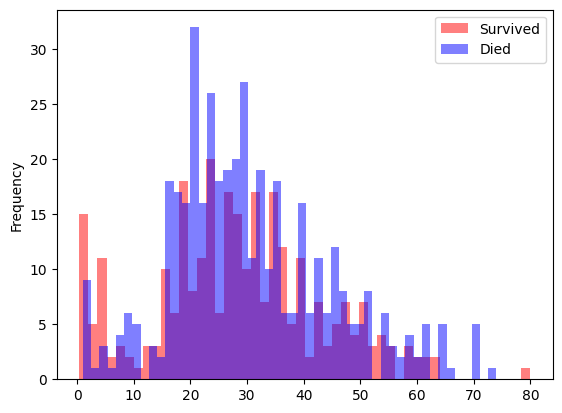

In [48]:
survived = train_data[train_data["Survived"] == 1]
died = train_data[train_data["Survived"] == 0]
survived["Age"].plot.hist(alpha=0.5,color='red',bins=50)
died["Age"].plot.hist(alpha=0.5,color='blue',bins=50)
plt.legend(['Survived','Died'])
plt.show()

From the graph, there are some range of ages that are more likely to survive i.e. the survival rate is higher such as children or infants. 

We can use "age range" instead of "age" for prediction 

## 2.4 Exploring the "Name" column

In [49]:
train_data["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

We can try to extract the title of the name and see if it useful information. Here are some protocols:

In [50]:
def extract_title(df):
    # Regex: Look for a word followed by a period
    # [A-Za-z]+ matches letters, \. matches the literal period
    df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
    return df

# Test: apply to train data
train = extract_title(train_data)
train['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

After extraction, there are many unique titles (e.g., "Don", "Major", "Capt", "Jonkheer"). If keeping them all, they will leads to overfitting.

In [51]:
# Group the rare titles into categories.
def group_titles(df):
    # Map rare titles to 'Rare' or common equivalents
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 
                                       'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    return df

train = group_titles(train)

In [52]:
train = group_titles(train)
train['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

## 2.5 Exploring the "Pclass" column
Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd

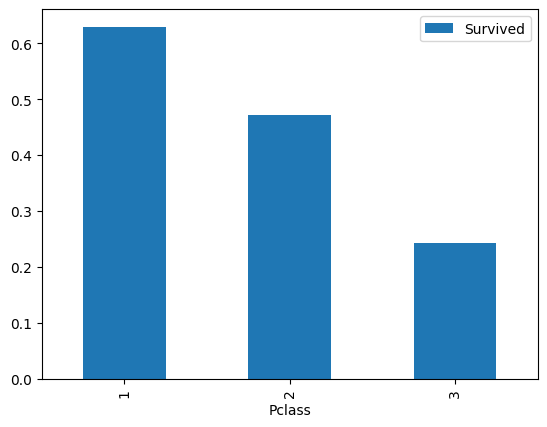

In [53]:
# Check how 'Class' related to Survived
class_pivot = train_data.pivot_table(index="Pclass",values="Survived")
class_pivot.plot.bar()
plt.show()

The passengers within the first class are more likely to survive compared to the other classes followed by the second and the third classes.

This column has to be transformed using onehotencoder.

## 2.6 Exploring the "Embarked" column

In [54]:
train_data["Embarked"].isna().sum()

np.int64(2)

In [55]:
train_data.groupby(["Embarked"]).size()

Embarked
C    168
Q     77
S    644
dtype: int64

S is the most frequent value -> can fill the two missing values with "S"|

## 2.7 Exploring the "Cabin" column

In [56]:
train_data["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

It is a unique data that were assigned based on deck and class. We can extract the deck data from this column

## 2.8 Exploring the "SibSp" and the "ParCh" columns

In [57]:
train_data[["SibSp", "Parch"]]

,SibSp,Parch
0,1,0
1,1,0
2,0,0
3,1,0
4,0,0
...,...,...
886,0,0
887,0,0
888,1,2
889,0,0


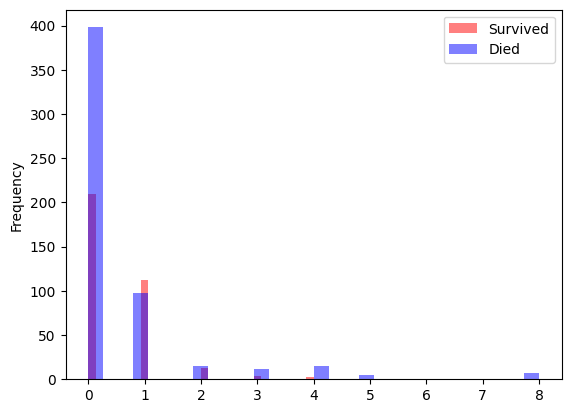

In [58]:
survived = train_data[train_data["Survived"] == 1]
died = train_data[train_data["Survived"] == 0]
survived["SibSp"].plot.hist(alpha=0.5,color='red',bins=30)
died["SibSp"].plot.hist(alpha=0.5,color='blue',bins=30)
plt.legend(['Survived','Died'])
plt.show()

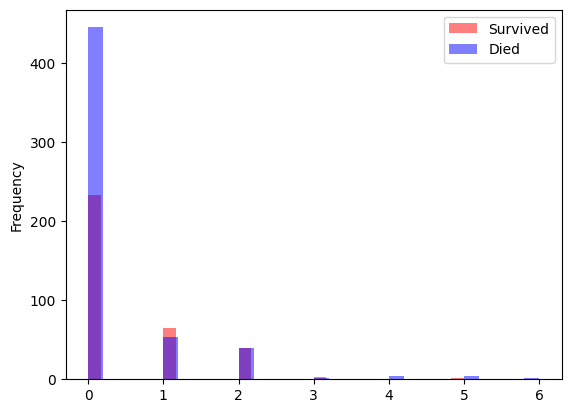

In [59]:
survived = train_data[train_data["Survived"] == 1]
died = train_data[train_data["Survived"] == 0]
survived["Parch"].plot.hist(alpha=0.5,color='red',bins=30)
died["Parch"].plot.hist(alpha=0.5,color='blue',bins=30)
plt.legend(['Survived','Died'])
plt.show()

Seems like if there is no SibSp and/or Parch. The Survival rate is high. 

We can merge the two column together as it follow the same trend.

## 2.9 Exploring the "Ticket" and the "Fare" columns

In [60]:
train_data["Ticket"].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

Seems like there is no useful information. It could be droped.

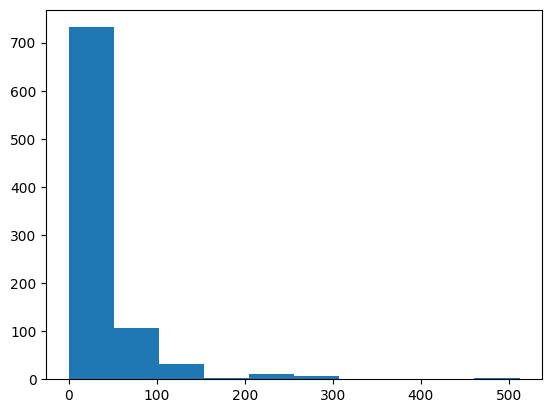

In [61]:
plt.hist(train_data["Fare"],10);

This data could be used and might need scaling.

In [62]:
# Define X_train, y_train
X_train = train_data.drop("Survived", axis=1)
y_train = train_data["Survived"]

# 3. Define Custom Transformers

## 3.1 **AgeCategoryTransformer:** transforming the "Age" column

In [66]:
class AgeCategoryTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cut_points=[-1, 0, 18, 100], label_names=None):
        self.cut_points = cut_points
        self.label_names = label_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # 1. Safety Check: Convert to DataFrame for indexing
        if not isinstance(X, (pd.DataFrame, pd.Series)):
            X = pd.DataFrame(X)
        
        # 2. Logic: Only use labels if they match the number of bins
        # Bins = Edges - 1
        num_bins = len(self.cut_points) - 1
        
        if self.label_names is not None and len(self.label_names) == num_bins:
            labels_to_use = self.label_names
        else:
            labels_to_use = None # Falls back to interval strings like "(18, 35]"
            
        # 3. Apply Binning
        # Using .iloc[:, 0] ensures we get the Age column regardless of its name
        age_bins = pd.cut(X.iloc[:, 0], bins=self.cut_points, labels=labels_to_use)
        
        # 4. Convert to String so OneHotEncoder can process the categories
        return pd.DataFrame(age_bins).astype(str)

    def get_feature_names_out(self, input_features=None):
        # This tells the pipeline the output column is named 'Age_Bin'
        return np.array(['Age_Bin'], dtype=object)

## 3.2 **TitleExtractor:** transforming the "Name" column

In [67]:
class TitleExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # If X is a numpy array, turn it back into a DataFrame
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        X = X.copy()
        # Extract
        X['Title'] = X['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
        # Grouping
        X['Title'] = X['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 
                                         'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
        X['Title'] = X['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
        return X[['Title']] # Return just the column for the next step in pipeline

    def get_feature_names_out(self, input_features=None):
        return np.array(['Title'], dtype=object)

## 3.3 **DeckExtractor:** transforming the "Cabin" column

Extract the deck data from the cabin column and fil the missing values with 'U' = unkmnown

In [68]:
class DeckExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # If X is a numpy array, turn it back into a DataFrame
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        X = X.copy()
        # 1. Fill missing cabins with 'U' (Unknown)
        X['Cabin'] = X['Cabin'].fillna('U')
        # 2. Extract the first letter (the Deck)
        X['Deck'] = X['Cabin'].map(lambda x: x[0])
        # 3. Handle rare decks (like 'T') by grouping them with 'U' or similar
        X['Deck'] = X['Deck'].replace(['T'], 'U') 
        return X[['Deck']]

    def get_feature_names_out(self, input_features=None):
        return np.array(['Deck'], dtype=object)

## **3.4 FamilySizeTransformer:** transforming SibSp and Parch columns

In [71]:
class FamilySizeTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert to a format that supports .iloc regardless of input type
        if not isinstance(X, (pd.DataFrame, pd.Series)):
            X = pd.DataFrame(X)
        
        # Access by position (0 and 1) instead of names ('SibSp', 'Parch')
        # This prevents the IndexError entirely
        family_size = X.iloc[:, 0] + X.iloc[:, 1] + 1
        
        # Return as a 2D DataFrame to keep the pipeline happy
        return pd.DataFrame(family_size, columns=['FamilySize'])

    def get_feature_names_out(self, input_features=None):
        return np.array(['FamilySize'], dtype=object)

# 4. Assemble the Pipeline and Optimization

All the pipeline lists:
1. **pclass**: OneHotEncoder, 3 columns	
2. **sex**: OneHotEncoder, 2 columns	
3. **Age**: AgeCategoryTransformer+ OneHotEncoder
4. **Name**: TitleExtractor+ OneHotEncoder
5. **sibsp+parch**: FamilySizeTransformer	
6. **ticket**: drop	
7. **fare**: StandardScaler()	
8. **cabin**: DeckExtractor+OneHotEncoder 
9. **embarked**: SimpleImputer(strategy='most_frequent')+OneHotEncoder

In [72]:
cut_points = [-1,0,5,12,18,35,60,100] # Can be optimized later
label_names = ["Missing","Infant","Child","Teenager","Young Adult","Adult","Senior"]

# Pipeline for all the columns (2+ methods)

# 1. Pipeline for Age 
age_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('binning', AgeCategoryTransformer(cut_points, label_names)),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# 2. Pipeline for Title (name)
title_pipeline = Pipeline([
    ('ext', TitleExtractor()),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# 3. Pipeline for Deck (cabin)
deck_pipeline = Pipeline([
    ('ext', DeckExtractor()),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Pipeline for Fare
fare_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# 5. Pipeline for Embarked
embarked_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])



In [73]:
# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('pclass_proc', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Pclass']),
        ('sex_proc', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Sex']),
        ('age_proc', age_pipeline, ['Age']),
        ('title_proc', title_pipeline, ['Name']),
        ('family_proc', FamilySizeTransformer(), ['SibSp', 'Parch']),
        ('fare_proc', fare_pipeline, ['Fare']),
        ('deck_proc', deck_pipeline, ['Cabin']), 
        ('embarked_proc', embarked_pipeline, ['Embarked'])
    ],
    remainder='drop'
)

# 5. The Final Fit

In [75]:
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10],
    'preprocessor__age_proc__binning__cut_points': [
        [-1, 0, 18, 100],                           # 3 bins
        [-1, 0, 12, 18, 35, 60, 100],               # 6 bins
        [-1, 0, 5, 12, 18, 35, 60, 100]             # 7 bins
    ]
}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Accuracy: {grid_search.best_score_:.2%}")
print(f"Optimal Parameters: {grid_search.best_params_}")

Best Accuracy: 82.94%
Optimal Parameters: {'model__max_depth': 5, 'model__n_estimators': 200, 'preprocessor__age_proc__binning__cut_points': [-1, 0, 12, 18, 35, 60, 100]}


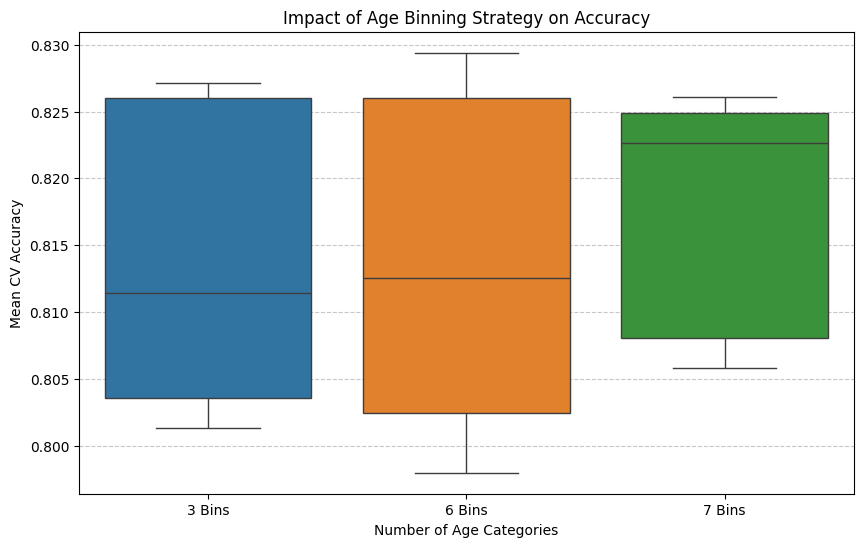

In [76]:
# Extracting the Grid Results

# Convert the grid results to a DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Clean up the 'cut_points' labels for the x-axis
results_df['age_bins_label'] = results_df['param_preprocessor__age_proc__binning__cut_points'].apply(lambda x: f"{len(x)-1} Bins")

# Plotting the performance
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_bins_label', y='mean_test_score', data=results_df, hue = 'age_bins_label', legend=False)
plt.title('Impact of Age Binning Strategy on Accuracy')
plt.ylabel('Mean CV Accuracy')
plt.xlabel('Number of Age Categories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


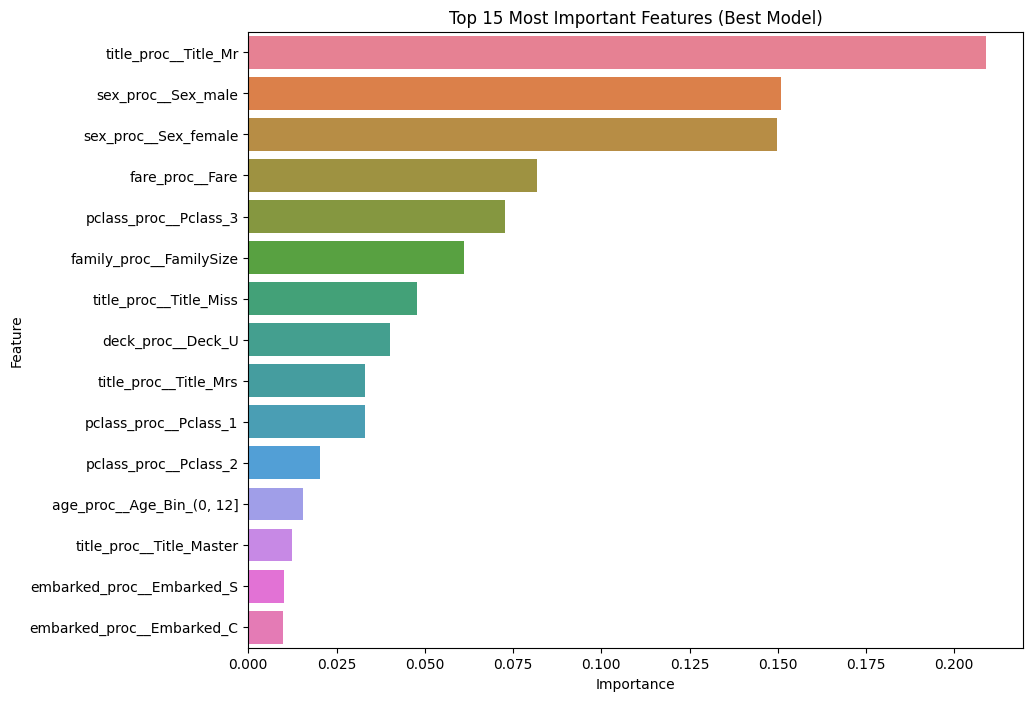

In [79]:
# Get the best estimator
best_model = grid_search.best_estimator_

# Get feature names from the preprocessor
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
# Get importances
importances = best_model.named_steps['model'].feature_importances_

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, hue='Feature', legend=False)
plt.title('Top 15 Most Important Features (Best Model)')
plt.show()

# 6. The Test Prediction

In [80]:
# 1. Use the best model from your GridSearch to predict
# This handles all the feature engineering automatically!
final_predictions = grid_search.best_estimator_.predict(test_data)

# 2. Create a DataFrame in the format Kaggle requires
submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": final_predictions
})

# 3. Save to CSV
submission.to_csv("titanic_submission.csv", index=False)

print("✅ Submission file 'titanic_submission.csv' is ready!")
print(submission.head())

✅ Submission file 'titanic_submission.csv' is ready!
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


In [81]:
survival_rate = submission['Survived'].mean()
print(f"Predicted Survival Rate: {survival_rate:.2%}")

if survival_rate < 0.20 or survival_rate > 0.50:
    print("⚠️ Warning: Your survival rate seems unusual. Check your preprocessing!")
else:
    print("🚀 Survival rate looks realistic for a Titanic model.")

Predicted Survival Rate: 38.76%
🚀 Survival rate looks realistic for a Titanic model.


# 7. Save the model

In [83]:
import joblib

# 1. Define the filename
filename = 'titanic_model_v1.pkl'

# 2. Save the best pipeline (preprocessor + model)
joblib.dump(grid_search.best_estimator_, filename)

print(f"✅ Model saved successfully as '{filename}'")

✅ Model saved successfully as 'titanic_model_v1.pkl'


In [ ]:
# # 1. Load the model back into memory
# loaded_clf = joblib.load('titanic_model_v1.pkl')

# # 2. Use it directly on new raw data
# # (Assuming 'new_data' is a DataFrame with the same original columns)
# new_predictions = loaded_clf.predict(new_data)

# print("Predictions from loaded model:", new_predictions[:5])